# ESP32 Blinkererkennung mit MFCC + linearem Modell

Dieses Notebook ist auf die Randbedingungen des Projekts zugeschnitten:

- `MicroPython` auf dem ESP32
- kein `TensorFlow Lite`
- kein `CNN`
- robuste Erkennung trotz wenig Trainingsdaten
- 1s Audio als stabile Eingabe
- Klassen: `blinker_links`, `blinker_rechts`, `unknown`

Die Idee ist bewusst simpel und deployment-freundlich:

1. 1s Audio normalisieren und auf feste L?nge bringen
2. MFCC-Features berechnen
3. Zeitlich poolen zu einem kompakten Feature-Vektor
4. lineares Modell trainieren
5. Gewichte + Skalierung + Schwellen f?r den ESP32 exportieren

Warum das bei wenig Daten oft besser funktioniert als ein CNN:

- weniger Modellparameter
- weniger Overfitting
- leichter mit Augmentation stabilisierbar
- Inferenz auf dem ESP32 ist nur Matrixmultiplikation + Softmax


In [11]:
from pathlib import Path
import json
import random
import warnings

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)


In [12]:
# ============================
# Konfiguration
# ============================
SR = 16_000
TARGET_SECONDS = 1.0
TARGET_SAMPLES = int(SR * TARGET_SECONDS)

FEATURE_KIND = 'mfcc'       # Alternativ: 'logmel'
N_MFCC = 13
N_MELS = 26
N_FFT = 512
HOP_LENGTH = 160            # 10 ms bei 16 kHz
WIN_LENGTH = 400            # 25 ms bei 16 kHz
FMIN = 50
FMAX = 4_000

TARGET_TRAIN_SAMPLES_PER_CLASS = 480
VALID_SIZE = 0.2
MAX_FILES_PER_CLASS = None  # z.B. 160, falls du hart begrenzen willst

EXPORT_PATH = 'esp32_blinker_mfcc_logreg.json'

DATA_ROOT = Path('data')

CLASS_DIRS = {
    'blinker_links': [DATA_ROOT / 'blinker_links'],
    'blinker_rechts': [DATA_ROOT / 'blinker_rechts'],
    'unknown': [
        DATA_ROOT / 'unknown',
    ],
}

AUDIO_EXTENSIONS = {'.wav', '.mp3', '.m4a', '.ogg', '.flac'}
LABELS = list(CLASS_DIRS.keys())
print(LABELS)


['blinker_links', 'blinker_rechts', 'unknown']


In [13]:
def list_audio_files(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob('*') if p.suffix.lower() in AUDIO_EXTENSIONS])


def collect_dataset(class_dirs, max_files_per_class=None):
    records = []
    for label, folders in class_dirs.items():
        files = []
        for folder in folders:
            files.extend(list_audio_files(folder))
        files = sorted(files)
        if max_files_per_class is not None:
            files = files[:max_files_per_class]
        for path in files:
            records.append({'path': str(path), 'label': label})
    return pd.DataFrame(records)


df = collect_dataset(CLASS_DIRS, max_files_per_class=MAX_FILES_PER_CLASS)
display(df.head())
print(df['label'].value_counts())
print(f'Gesamt: {len(df)} Dateien')


,path,label
0,data\blinker_links\MiniMax_2026-05-05_16_43_17...,blinker_links
1,data\blinker_links\MiniMax_2026-05-05_16_43_17...,blinker_links
2,data\blinker_links\MiniMax_2026-05-05_16_43_17...,blinker_links
3,data\blinker_links\MiniMax_2026-05-05_16_43_17...,blinker_links
4,data\blinker_links\MiniMax_2026-05-05_16_43_17...,blinker_links


label
blinker_links     167
blinker_rechts    166
unknown             6
Name: count, dtype: int64
Gesamt: 339 Dateien


blinker_rechts data\blinker_rechts\WhatsApp_Ptt_2026-05-19_at_19_30_37_0022_blinker_rechts_tempo.wav


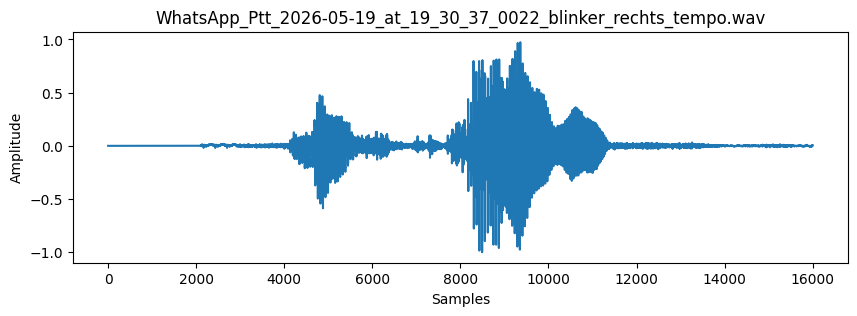

In [14]:
def load_audio_1s(path, sr=SR, target_samples=TARGET_SAMPLES):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    audio = np.nan_to_num(audio).astype(np.float32)

    if len(audio) < target_samples:
        pad = target_samples - len(audio)
        audio = np.pad(audio, (0, pad), mode='constant')
    elif len(audio) > target_samples:
        energy = np.convolve(audio ** 2, np.ones(min(512, len(audio))), mode='same')
        center = int(np.argmax(energy))
        start = max(0, center - target_samples // 2)
        end = start + target_samples
        if end > len(audio):
            end = len(audio)
            start = end - target_samples
        audio = audio[start:end]

    peak = np.max(np.abs(audio)) + 1e-8
    audio = audio / peak
    return audio.astype(np.float32)


def show_wave(path):
    audio = load_audio_1s(path)
    plt.figure(figsize=(10, 3))
    plt.plot(audio)
    plt.title(Path(path).name)
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.show()

sample_row = df.sample(1, random_state=42).iloc[0]
print(sample_row['label'], sample_row['path'])
show_wave(sample_row['path'])


In [15]:
# Hintergrund-Rauschen f?r Augmentation vorladen
background_paths = []
for folder in CLASS_DIRS['unknown']:
    if folder.name == '_background_noise_' and folder.exists():
        background_paths.extend(list_audio_files(folder))

background_cache = [load_audio_1s(p) for p in background_paths]
print(f'Geladene Hintergrund-Clips: {len(background_cache)}')


Geladene Hintergrund-Clips: 0


In [16]:
def maybe_time_shift(audio, max_shift=0.12):
    shift = int(np.random.uniform(-max_shift, max_shift) * len(audio))
    if shift == 0:
        return audio
    return np.roll(audio, shift)


def maybe_gain(audio, min_gain=0.75, max_gain=1.25):
    gain = np.random.uniform(min_gain, max_gain)
    return audio * gain


def maybe_dropout(audio, max_fraction=0.10):
    if np.random.rand() < 0.5:
        return audio
    width = int(len(audio) * np.random.uniform(0.02, max_fraction))
    start = np.random.randint(0, max(1, len(audio) - width))
    out = audio.copy()
    out[start:start + width] = 0.0
    return out


def maybe_mix_background(audio, bg_cache, snr_db_range=(8, 22)):
    if not bg_cache or np.random.rand() < 0.35:
        return audio
    noise = random.choice(bg_cache).copy()
    if len(noise) != len(audio):
        noise = librosa.util.fix_length(noise, size=len(audio))
    sig_rms = np.sqrt(np.mean(audio ** 2) + 1e-8)
    noise_rms = np.sqrt(np.mean(noise ** 2) + 1e-8)
    snr_db = np.random.uniform(*snr_db_range)
    desired_noise_rms = sig_rms / (10 ** (snr_db / 20.0))
    noise = noise * (desired_noise_rms / (noise_rms + 1e-8))
    return audio + noise


def maybe_pitch_shift(audio, sr=SR):
    if np.random.rand() < 0.6:
        return audio
    steps = np.random.uniform(-0.6, 0.6)
    shifted = librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)
    return librosa.util.fix_length(shifted, size=len(audio))


def maybe_time_stretch(audio):
    if np.random.rand() < 0.6:
        return audio
    rate = np.random.uniform(0.92, 1.08)
    stretched = librosa.effects.time_stretch(audio, rate=rate)
    return librosa.util.fix_length(stretched, size=len(audio))


def augment_audio(audio, label, bg_cache):
    out = audio.copy()
    out = maybe_time_shift(out)
    out = maybe_gain(out)
    out = maybe_dropout(out)
    out = maybe_mix_background(out, bg_cache)

    # F?r Sprachkommandos sind kleine Tonh?hen- und Tempo-?nderungen hilfreich.
    if label != 'unknown':
        out = maybe_pitch_shift(out)
        out = maybe_time_stretch(out)

    peak = np.max(np.abs(out)) + 1e-8
    out = np.clip(out / peak, -1.0, 1.0)
    return out.astype(np.float32)


In [17]:
def extract_frame_features(audio, sr=SR, feature_kind=FEATURE_KIND):
    if feature_kind == 'mfcc':
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0,
        )
        log_mel = librosa.power_to_db(mel + 1e-10)
        base = librosa.feature.mfcc(S=log_mel, n_mfcc=N_MFCC)
    elif feature_kind == 'logmel':
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0,
        )
        base = librosa.power_to_db(mel + 1e-10)
    else:
        raise ValueError(f'Unbekannter Feature-Typ: {feature_kind}')

    delta = librosa.feature.delta(base)
    delta2 = librosa.feature.delta(base, order=2)
    rms = librosa.feature.rms(y=audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    return base, delta, delta2, rms


def pool_stats(matrix):
    return np.concatenate([
        matrix.mean(axis=1),
        matrix.std(axis=1),
        np.percentile(matrix, 10, axis=1),
        np.percentile(matrix, 90, axis=1),
    ]).astype(np.float32)


def extract_feature_vector(audio, sr=SR, feature_kind=FEATURE_KIND):
    base, delta, delta2, rms = extract_frame_features(audio, sr=sr, feature_kind=feature_kind)
    vec = np.concatenate([
        pool_stats(base),
        pool_stats(delta),
        pool_stats(delta2),
        np.array([
            rms.mean(),
            rms.std(),
            np.percentile(rms, 10),
            np.percentile(rms, 90),
        ], dtype=np.float32).reshape(-1),
    ]).astype(np.float32)
    return vec


def feature_dim(feature_kind=FEATURE_KIND):
    bands = N_MFCC if feature_kind == 'mfcc' else N_MELS
    return bands * 4 * 3 + 4

print('Feature-Dimension:', feature_dim())


Feature-Dimension: 160


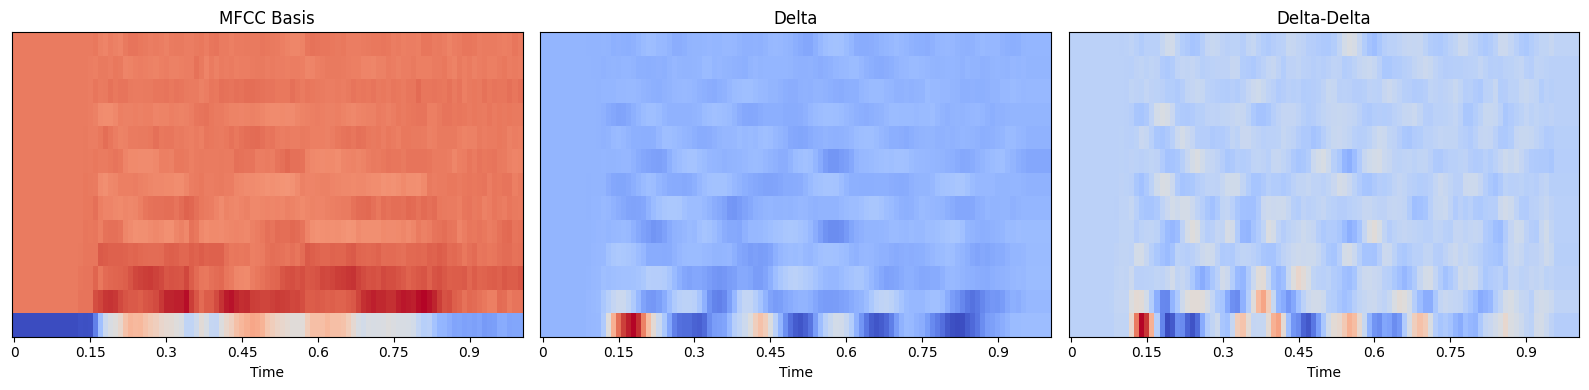

In [18]:
# Beispiel: Features eines Clips visualisieren
example_audio = load_audio_1s(df.iloc[0]['path'])
base, delta, delta2, rms = extract_frame_features(example_audio)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
librosa.display.specshow(base, x_axis='time', ax=axes[0], sr=SR, hop_length=HOP_LENGTH)
axes[0].set_title(f'{FEATURE_KIND.upper()} Basis')
librosa.display.specshow(delta, x_axis='time', ax=axes[1], sr=SR, hop_length=HOP_LENGTH)
axes[1].set_title('Delta')
librosa.display.specshow(delta2, x_axis='time', ax=axes[2], sr=SR, hop_length=HOP_LENGTH)
axes[2].set_title('Delta-Delta')
plt.tight_layout()
plt.show()


In [19]:
# Vor dem Augmentieren splitten, damit keine Leckage zwischen Train und Valid entsteht.
train_df, valid_df = train_test_split(
    df,
    test_size=VALID_SIZE,
    random_state=42,
    stratify=df['label']
)

print('Train-Verteilung:')
print(train_df['label'].value_counts())
print('Valid-Verteilung:')
print(valid_df['label'].value_counts())


Train-Verteilung:
label
blinker_links     133
blinker_rechts    133
unknown             5
Name: count, dtype: int64
Valid-Verteilung:
label
blinker_links     34
blinker_rechts    33
unknown            1
Name: count, dtype: int64


In [20]:
def build_feature_table(split_df, bg_cache, augment=False, target_per_class=None):
    rows = []

    grouped = {label: split_df[split_df['label'] == label].to_dict('records') for label in LABELS}

    if augment and target_per_class is not None:
        for label, records in grouped.items():
            for i in range(target_per_class):
                row = records[i % len(records)]
                audio = load_audio_1s(row['path'])
                audio = augment_audio(audio, label, bg_cache)
                vec = extract_feature_vector(audio)
                rows.append({
                    'label': label,
                    'path': row['path'],
                    'augmented': True,
                    'features': vec,
                })
    else:
        for _, row in split_df.iterrows():
            audio = load_audio_1s(row['path'])
            vec = extract_feature_vector(audio)
            rows.append({
                'label': row['label'],
                'path': row['path'],
                'augmented': False,
                'features': vec,
            })

    out = pd.DataFrame(rows)
    X = np.stack(out['features'].values)
    y = out['label'].values
    return out, X, y

train_features_df, X_train, y_train = build_feature_table(
    train_df,
    bg_cache=background_cache,
    augment=True,
    target_per_class=TARGET_TRAIN_SAMPLES_PER_CLASS,
)

valid_features_df, X_valid, y_valid = build_feature_table(
    valid_df,
    bg_cache=background_cache,
    augment=False,
)

print(X_train.shape, X_valid.shape)
print(pd.Series(y_train).value_counts())


(1440, 160) (68, 160)
blinker_links     480
blinker_rechts    480
unknown           480
Name: count, dtype: int64


In [21]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=3000,
        solver='lbfgs',
        C=2.0,
        class_weight='balanced',
        multi_class='auto',
    ))
])

model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)
valid_proba = model.predict_proba(X_valid)

print(classification_report(y_valid, valid_pred, digits=4))


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
labels_in_model = model.named_steps['clf'].classes_.tolist()
cm = confusion_matrix(y_valid, valid_pred, labels=labels_in_model)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_in_model)
disp.plot(cmap='Blues', values_format='d')
plt.title('Validierungs-Confusion-Matrix')
plt.show()


In [ ]:
# Zus?tzliche Reject-Regeln f?r robustes 'unknown'-Verhalten.
# Auch wenn das Modell 3 Klassen kennt, hilft eine Sicherheitsgrenze gegen unsichere Vorhersagen.

def compute_margin(prob_row):
    sorted_probs = np.sort(prob_row)
    if len(sorted_probs) < 2:
        return float(sorted_probs[-1])
    return float(sorted_probs[-1] - sorted_probs[-2])

best_probs = valid_proba.max(axis=1)
margins = np.array([compute_margin(row) for row in valid_proba])
true_is_unknown = (y_valid == 'unknown')

candidate_conf = np.linspace(0.40, 0.85, 19)
candidate_margin = np.linspace(0.02, 0.30, 15)

best_score = -1.0
best_thresholds = (0.55, 0.08)

for conf_thr in candidate_conf:
    for margin_thr in candidate_margin:
        adjusted = []
        for pred, prob, margin in zip(valid_pred, best_probs, margins):
            if prob < conf_thr or margin < margin_thr:
                adjusted.append('unknown')
            else:
                adjusted.append(pred)
        score = f1_score(y_valid, adjusted, average='macro')
        if score > best_score:
            best_score = score
            best_thresholds = (float(conf_thr), float(margin_thr))

MIN_CONFIDENCE, MIN_MARGIN = best_thresholds
print('Beste Reject-Schwellen:')
print('MIN_CONFIDENCE =', MIN_CONFIDENCE)
print('MIN_MARGIN =', MIN_MARGIN)
print('Macro-F1 =', best_score)


In [ ]:
def predict_with_reject(feature_matrix, model, min_confidence, min_margin):
    proba = model.predict_proba(feature_matrix)
    classes = model.named_steps['clf'].classes_
    preds = []
    confs = []
    margins = []

    for row in proba:
        idx = int(np.argmax(row))
        conf = float(row[idx])
        margin = compute_margin(row)
        pred = str(classes[idx])
        if conf < min_confidence or margin < min_margin:
            pred = 'unknown'
        preds.append(pred)
        confs.append(conf)
        margins.append(margin)

    return np.array(preds), np.array(confs), np.array(margins), proba

valid_pred_reject, valid_conf, valid_margin, valid_proba = predict_with_reject(
    X_valid, model, MIN_CONFIDENCE, MIN_MARGIN
)

print(classification_report(y_valid, valid_pred_reject, digits=4))


In [ ]:
scaler = model.named_steps['scaler']
clf = model.named_steps['clf']

export_bundle = {
    'model_type': 'standardized_logistic_regression',
    'labels': clf.classes_.tolist(),
    'feature_kind': FEATURE_KIND,
    'sample_rate': SR,
    'target_seconds': TARGET_SECONDS,
    'target_samples': TARGET_SAMPLES,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'win_length': WIN_LENGTH,
    'n_mfcc': N_MFCC,
    'n_mels': N_MELS,
    'fmin': FMIN,
    'fmax': FMAX,
    'feature_dim': int(X_train.shape[1]),
    'scaler_mean': scaler.mean_.astype(float).tolist(),
    'scaler_scale': scaler.scale_.astype(float).tolist(),
    'weights': clf.coef_.astype(float).tolist(),
    'bias': clf.intercept_.astype(float).tolist(),
    'min_confidence': float(MIN_CONFIDENCE),
    'min_margin': float(MIN_MARGIN),
}

with open(EXPORT_PATH, 'w', encoding='utf-8') as f:
    json.dump(export_bundle, f, indent=2)

print(f'Export geschrieben: {EXPORT_PATH}')
print(f'Labels: {export_bundle["labels"]}')
print(f'Feature-Dim: {export_bundle["feature_dim"]}')


## MicroPython-Deployment-Idee

Auf dem ESP32 brauchst du dann nur noch drei Bausteine:

1. Audioaufnahme von genau 1s bei `16 kHz`
2. dieselbe MFCC-Extraktion wie im Notebook
3. lineare Inferenz mit den exportierten Gewichten

Die Inferenz selbst ist sehr leicht:

- Features standardisieren: `(x - mean) / scale`
- pro Klasse Score berechnen: `score = W ? x + b`
- Softmax f?r Wahrscheinlichkeiten
- wenn `max_prob < min_confidence` oder `margin < min_margin` dann `unknown`

Der teure Teil ist also nicht das Modell, sondern die Feature-Extraktion. Genau deshalb ist ein lineares Modell f?r den ESP32 viel angenehmer als ein CNN.


In [ ]:
# Referenz-Inferenz in reinem Python, analog zu dem, was sp?ter auf dem ESP32 l?uft.
def softmax(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / (np.sum(ex) + 1e-8)


def predict_from_export(audio, bundle):
    feat = extract_feature_vector(audio, feature_kind=bundle['feature_kind'])
    x = (feat - np.array(bundle['scaler_mean'], dtype=np.float32)) / (
        np.array(bundle['scaler_scale'], dtype=np.float32) + 1e-8
    )
    W = np.array(bundle['weights'], dtype=np.float32)
    b = np.array(bundle['bias'], dtype=np.float32)
    logits = W @ x + b
    probs = softmax(logits)

    best_idx = int(np.argmax(probs))
    best_prob = float(probs[best_idx])
    sorted_probs = np.sort(probs)
    margin = float(sorted_probs[-1] - sorted_probs[-2]) if len(sorted_probs) > 1 else best_prob
    pred = bundle['labels'][best_idx]

    if best_prob < bundle['min_confidence'] or margin < bundle['min_margin']:
        pred = 'unknown'

    return {
        'prediction': pred,
        'best_prob': best_prob,
        'margin': margin,
        'probs': {label: float(prob) for label, prob in zip(bundle['labels'], probs)}
    }

with open(EXPORT_PATH, 'r', encoding='utf-8') as f:
    exported = json.load(f)

example_path = valid_df.sample(1, random_state=7).iloc[0]['path']
example_audio = load_audio_1s(example_path)
result = predict_from_export(example_audio, exported)
print(Path(example_path).name)
print(result)


## Hinweise f?r wenig Daten

Wenn die Erkennung noch instabil ist, sind diese drei Stellschrauben meistens am wirksamsten:

1. mehr echte `unknown`-Daten sammeln
   - am besten direkt in `data/unknown`
2. harte Negativbeispiele hinzuf?gen
   - andere Sprachbefehle
   - Fahrger?usche
   - Musik
   - Mikrofonber?hrungen
3. das Modell konservativer machen
   - `MIN_CONFIDENCE` erh?hen
   - `MIN_MARGIN` erh?hen

F?r ein eingebettetes Wakeword-?hnliches System ist ein gutes `unknown`-Set oft wichtiger als ein gr??eres Modell.


In [ ]:
# Optional: einzelne Datei testen
# test_path = r'data/blinker_links/deine_datei.wav'
# test_audio = load_audio_1s(test_path)
# print(predict_from_export(test_audio, exported))
